# Imports

In [1]:
import os
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

## Set current dir to project root dir

In [2]:
def find_project_root():
    """Walk up from CWD until we find the project root."""
    markers = [".git", "Makefile", "renv.lock", ".Rprofile"]
    path = Path.cwd()
    while path != path.parent:
        if any((path / m).exists() for m in markers):
            return path
        path = path.parent
    raise FileNotFoundError("Could not find project root")

os.chdir(find_project_root())

In [3]:
# 1. Read the pkl file
with open("./ds006018_functional/sub-001/task-auditoryoddball_Stimulus_S1.pkl", "rb") as f:
    eeg_fd = pickle.load(f)

# Quick look at the structure
print(eeg_fd)

Data set:    [[[ 8.48138960e+00]
  [ 6.46894370e+00]
  [ 4.65148531e+00]
  [ 3.02079263e+00]
  [ 1.56864391e+00]
  [ 2.86817381e-01]
  [-8.32908741e-01]
  [-1.79875622e+00]
  [-2.61894683e+00]
  [-3.30170234e+00]
  [-3.85524452e+00]
  [-4.28779514e+00]
  [-4.60757597e+00]
  [-4.82280879e+00]
  [-4.94171536e+00]
  [-4.97251746e+00]
  [-4.92343686e+00]
  [-4.80269532e+00]
  [-4.61851462e+00]
  [-4.37911653e+00]
  [-4.09272282e+00]
  [-3.76755526e+00]
  [-3.41183562e+00]
  [-3.03378568e+00]
  [-2.64162720e+00]
  [-2.24358195e+00]
  [-1.84787172e+00]
  [-1.46271825e+00]
  [-1.09634334e+00]
  [-7.56968742e-01]
  [-4.52478171e-01]
  [-1.85453473e-01]
  [ 4.57330804e-02]
  [ 2.42825171e-01]
  [ 4.07566483e-01]
  [ 5.41700700e-01]
  [ 6.46971504e-01]
  [ 7.25122579e-01]
  [ 7.77897609e-01]
  [ 8.07040275e-01]
  [ 8.14294263e-01]
  [ 8.01403254e-01]
  [ 7.70110932e-01]
  [ 7.22160981e-01]
  [ 6.59297083e-01]
  [ 5.83262922e-01]
  [ 4.95802181e-01]
  [ 3.98658544e-01]
  [ 2.93575693e-01]
  [ 1.8

In [4]:
# 2. Evaluate the functional data object at 500 time points
time_range = eeg_fd.domain_range[0]  # (-0.2, 0.8)
time_points = np.linspace(time_range[0], time_range[1], 500)

# evaluate() returns shape (n_samples, n_timepoints, 1)
amplitude_values = eeg_fd.evaluate(time_points).squeeze()

/tmp/ipykernel_3094222/2678725995.py:6: DeprecationWarning: The method 'evaluate' is deprecated. Please use the normal calling notation on the functional data object instead.
  amplitude_values = eeg_fd.evaluate(time_points).squeeze()


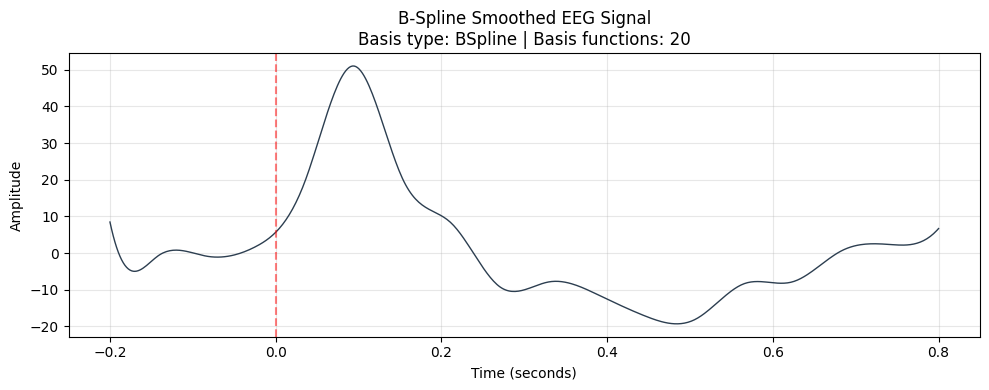

In [5]:
# 3. Visualize
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(time_points, amplitude_values.T, color="#2c3e50", linewidth=1)
ax.axvline(x=0, linestyle="--", color="red", alpha=0.5)
ax.set_title(
    f"B-Spline Smoothed EEG Signal\n"
    f"Basis type: BSpline | Basis functions: 20"
)
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()